# exp-gs-002-04 — H-AS + exact mutation 4개 ablation

## 목적

현재 best인 `H-AS-LR-exact`의 exact mutation 4개(BRAF V600E, IDH1 R132H, PIK3CA H1047R, PIK3CA E545K)를 하나씩 제외하여 개별 기여를 검증한다. 새 피처 탐색이나 조합은 수행하지 않는다.

모든 후보는 Logistic `lbfgs`, `C=0.07`, `max_iter=2000`, `class_weight=balanced`, Stratified 5-fold, seeds `42/2024/777`으로 비교한다. fold-train only, `leakage_check=True`, `nan_as_mutation_count=0` 조건을 유지한다.

## 후보와 판정

- 기준: `H-AS-LR-exact` — exact 4개 전체
- ablation: 각 exact 하나만 제외한 4개 후보
- 채택: 기준 대비 3-seed 평균 Macro F1이 개선되고, seed별 delta가 모두 양수인 제거 후보만 다음 제출 후보로 고려한다.
- 결과 CSV는 `eda_pre_002/result/`에 저장된다. 제출 파일은 이 노트북에서 생성하지 않으며, 향후 `experiments/gs/notebooks/submission/`에만 저장한다.

In [5]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:.6f}')


def find_eda_dir() -> Path:
    start = Path.cwd()
    for candidate in (start, *start.parents):
        direct = candidate / 'common' / 'exp-gs-002-memory-safe.py'
        from_project_root = candidate / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002' / 'common' / 'exp-gs-002-memory-safe.py'
        if direct.exists():
            return candidate
        if from_project_root.exists():
            return from_project_root.parent.parent
    raise FileNotFoundError('프로젝트 루트 또는 eda_pre_002에서 실행하세요.')


EDA_DIR = find_eda_dir()
ROOT = EDA_DIR.parents[3]
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'

RUN_ID = 'exp-gs-002-04'
MODEL = 'logistic'
SEEDS = (42, 2024, 777)
BASELINE = 'H-AS-LR-exact'
CANDIDATES = (
    BASELINE,
    'H-AS-LR-exact-minus-BRAF-V600E',
    'H-AS-LR-exact-minus-IDH1-R132H',
    'H-AS-LR-exact-minus-PIK3CA-H1047R',
    'H-AS-LR-exact-minus-PIK3CA-E545K',
)

assert RUNNER.exists(), RUNNER
assert RESULT_DIR.exists(), RESULT_DIR

{
    'runner': RUNNER,
    'result_dir': RESULT_DIR,
    'candidates': CANDIDATES,
    'seeds': SEEDS,
    'fixed_model': 'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced',
    'cv': 'StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)',
}

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'),
 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result'),
 'candidates': ('H-AS-LR-exact',
  'H-AS-LR-exact-minus-BRAF-V600E',
  'H-AS-LR-exact-minus-IDH1-R132H',
  'H-AS-LR-exact-minus-PIK3CA-H1047R',
  'H-AS-LR-exact-minus-PIK3CA-E545K'),
 'seeds': (42, 2024, 777),
 'fixed_model': 'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced',
 'cv': 'StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)'}

## 실행

기본값은 `False`다. 실제 실행 시에만 `True`로 바꾼다. 후보 5개 × seed 3개이며, 각 seed의 fold 진행은 공통 실행기의 tqdm으로 표시된다. 이미 존재하는 결과도 다시 실행하므로, 중단 후 재개할 때는 원하는 후보만 `CANDIDATES`에 남긴다.

In [6]:
RUN_EXPERIMENT = True

if RUN_EXPERIMENT:
    jobs = [(candidate, seed) for candidate in CANDIDATES for seed in SEEDS]
    for candidate, seed in tqdm(jobs, desc=f'{RUN_ID} | exact ablation', unit='run'):
        command = [
            sys.executable,
            str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', candidate,
            '--model', MODEL,
            '--seed', str(seed),
        ]
        completed = subprocess.run(command, cwd=ROOT, check=False)
        if completed.returncode != 0:
            raise RuntimeError(f'candidate={candidate}, seed={seed} 실행 실패 (returncode={completed.returncode})')
else:
    print('미실행 상태입니다. 실행하려면 RUN_EXPERIMENT = True로 변경하세요.')

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 380.23it/s]
H-AS-LR-exact | logistic | seed 42: 100%|██████████| 5/5 [04:55<00:00, 59.06s/it]


{
  "experiment_id": "H-AS-LR-exact",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.4312924774297094,
  "oof_accuracy": 0.42009353330108046,
  "fold_macro_f1_mean": 0.4304266365637842,
  "fold_macro_f1_std": 0.010892601328795146,
  "feature_count_mean": 8217.2,
  "runtime_seconds": 295.4031067909964,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 395.97it/s]run]
H-AS-LR-exact | logistic | seed 2024: 100%|██████████| 5/5 [04:51<00:00, 58.32s/it]


{
  "experiment_id": "H-AS-LR-exact",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4361044545065911,
  "oof_accuracy": 0.4228350266086115,
  "fold_macro_f1_mean": 0.4362236019964647,
  "fold_macro_f1_std": 0.008394835265655192,
  "feature_count_mean": 8217.0,
  "runtime_seconds": 291.670869374997,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 397.58it/s]run]
H-AS-LR-exact | logistic | seed 777: 100%|██████████| 5/5 [04:56<00:00, 59.24s/it]


...

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 401.61it/s]/run]
H-AS-LR-exact-minus-PIK3CA-E545K | logistic | seed 2024: 100%|██████████| 5/5 [04:45<00:00, 57.06s/it]


{
  "experiment_id": "H-AS-LR-exact-minus-PIK3CA-E545K",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4349034978063879,
  "oof_accuracy": 0.42170617642315755,
  "fold_macro_f1_mean": 0.4349363631157397,
  "fold_macro_f1_std": 0.00800923300852762,
  "feature_count_mean": 8216.0,
  "runtime_seconds": 285.4245647909993,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 398.15it/s]/run]
H-AS-LR-exact-minus-PIK3CA-E545K | logistic | seed 777: 100%|██████████| 5/5 [04:44<00:00, 56.96s/it]


{
  "experiment_id": "H-AS-LR-exact-minus-PIK3CA-E545K",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.43218986968690626,
  "oof_accuracy": 0.4225124979841961,
  "fold_macro_f1_mean": 0.4314872288459723,
  "fold_macro_f1_std": 0.011116425754004261,
  "feature_count_mean": 8211.4,
  "runtime_seconds": 284.89909016699676,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


exp-gs-002-04 | exact ablation: 100%|██████████| 15/15 [1:18:19<00:00, 313.29s/run]


## 3-seed 요약 및 기준 대비 비교

각 후보의 세 seed가 모두 생성된 경우에만 요약한다. `leakage_check=True`, `nan_as_mutation_count=0`이 아닌 결과는 오류로 중단한다.

In [7]:
def oof_path(candidate: str, seed: int) -> Path:
    return RESULT_DIR / f'{RUN_ID}_{candidate}_{MODEL}_seed{seed}_oof.csv'


expected = [oof_path(candidate, seed) for candidate in CANDIDATES for seed in SEEDS]
missing = [path for path in expected if not path.exists()]

if missing:
    print('아직 필요한 OOF 결과 파일이 없습니다:')
    for path in missing:
        print(' -', path.name)
else:
    runs = pd.concat([pd.read_csv(path) for path in expected], ignore_index=True)
    assert runs['leakage_check'].all(), 'leakage_check=False 결과가 있습니다.'
    assert (runs['nan_as_mutation_count'] == 0).all(), 'NaN이 mutation으로 처리된 결과가 있습니다.'

    summary = (
        runs.groupby(['experiment_id', 'model'], as_index=False)
        .agg(
            seed_count=('seed', 'nunique'),
            oof_macro_f1_mean=('oof_macro_f1', 'mean'),
            oof_macro_f1_std=('oof_macro_f1', 'std'),
            oof_accuracy_mean=('oof_accuracy', 'mean'),
            feature_count_mean=('feature_count_mean', 'mean'),
            runtime_seconds_mean=('runtime_seconds', 'mean'),
            convergence_warning_count=('convergence_warning_count', 'sum'),
            leakage_check=('leakage_check', 'all'),
            nan_as_mutation_count=('nan_as_mutation_count', 'max'),
        )
        .sort_values('experiment_id')
        .reset_index(drop=True)
    )
    baseline_mean = summary.loc[summary['experiment_id'].eq(BASELINE), 'oof_macro_f1_mean'].iloc[0]
    summary['delta_vs_exact4'] = summary['oof_macro_f1_mean'] - baseline_mean
    summary['all_seed_positive_vs_exact4'] = summary['experiment_id'].map(
        runs.pivot(index='seed', columns='experiment_id', values='oof_macro_f1').sub(
            runs.pivot(index='seed', columns='experiment_id', values='oof_macro_f1')[BASELINE], axis=0
        ).gt(0).all()
    ).fillna(False)
    summary['decision'] = '유지'
    accepted = (summary['experiment_id'].ne(BASELINE) & (summary['delta_vs_exact4'] > 0) & summary['all_seed_positive_vs_exact4'])
    summary.loc[accepted, 'decision'] = '제거 후보 채택'
    summary.loc[summary['experiment_id'].eq(BASELINE), 'decision'] = '기준'

    summary_path = RESULT_DIR / f'{RUN_ID}_exact_ablation_3seed_summary.csv'
    summary.to_csv(summary_path, index=False)
    display(runs.sort_values(['experiment_id', 'seed']))
    display(summary.sort_values('oof_macro_f1_mean', ascending=False))
    print(f'저장 완료: {summary_path.name}')

,experiment_id,model,seed,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,runtime_seconds,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-exact,logistic,42,0.431292,0.420094,0.430427,0.010893,8217.200000,295.403107,5,True,0
2,H-AS-LR-exact,logistic,777,0.433039,0.423641,0.432351,0.011392,8212.400000,296.283798,5,True,0
1,H-AS-LR-exact,logistic,2024,0.436104,0.422835,0.436224,0.008395,8217.000000,291.670869,5,True,0
3,H-AS-LR-exact-minus-BRAF-V600E,logistic,42,0.430584,0.420255,0.429790,0.011212,8216.200000,289.050692,5,True,0
5,H-AS-LR-exact-minus-BRAF-V600E,logistic,777,0.433206,0.423803,0.432476,0.012475,8211.400000,284.442734,5,True,0
4,H-AS-LR-exact-minus-BRAF-V600E,logistic,2024,0.434014,0.420900,0.434062,0.007337,8216.000000,288.001993,5,True,0
6,H-AS-LR-exact-minus-IDH1-R132H,logistic,42,0.430716,0.419448,0.429903,0.010962,8216.200000,286.471929,5,True,0
8,H-AS-LR-exact-minus-IDH1-R132H,logistic,777,0.432508,0.422674,0.431694,0.013223,8211.400000,290.139217,5,True,0
7,H-AS-LR-exact-minus-IDH1-R132H,logistic,2024,0.434258,0.420900,0.434318,0.008978,8216.000000,281.956271,4,True,0
12,H-AS-LR-exact-minus-PIK3CA-E545K,logistic,42,0.429473,0.418803,0.428611,0.012243,8216.200000,284.630807,5,True,0


,experiment_id,model,seed_count,oof_macro_f1_mean,oof_macro_f1_std,oof_accuracy_mean,feature_count_mean,runtime_seconds_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_exact4,all_seed_positive_vs_exact4,decision
0,H-AS-LR-exact,logistic,3,0.433479,0.002436,0.422190,8215.533333,294.452591,15,True,0,0.000000,False,기준
1,H-AS-LR-exact-minus-BRAF-V600E,logistic,3,0.432602,0.001793,0.421652,8214.533333,287.165140,15,True,0,-0.000877,False,유지
4,H-AS-LR-exact-minus-PIK3CA-H1047R,logistic,3,0.432571,0.002562,0.421437,8214.533333,285.643897,15,True,0,-0.000908,False,유지
2,H-AS-LR-exact-minus-IDH1-R132H,logistic,3,0.432494,0.001771,0.421007,8214.533333,286.189139,14,True,0,-0.000984,False,유지
3,H-AS-LR-exact-minus-PIK3CA-E545K,logistic,3,0.432189,0.002715,0.421007,8214.533333,284.984821,15,True,0,-0.001290,False,유지


저장 완료: exp-gs-002-04_exact_ablation_3seed_summary.csv


## 시각화와 최종 판정

평균 점수만 높아도 seed별 방향이 일관되지 않으면 제거하지 않는다. 수렴 경고가 기준보다 현저히 늘어난 후보도 보수적으로 유지 판정한다.

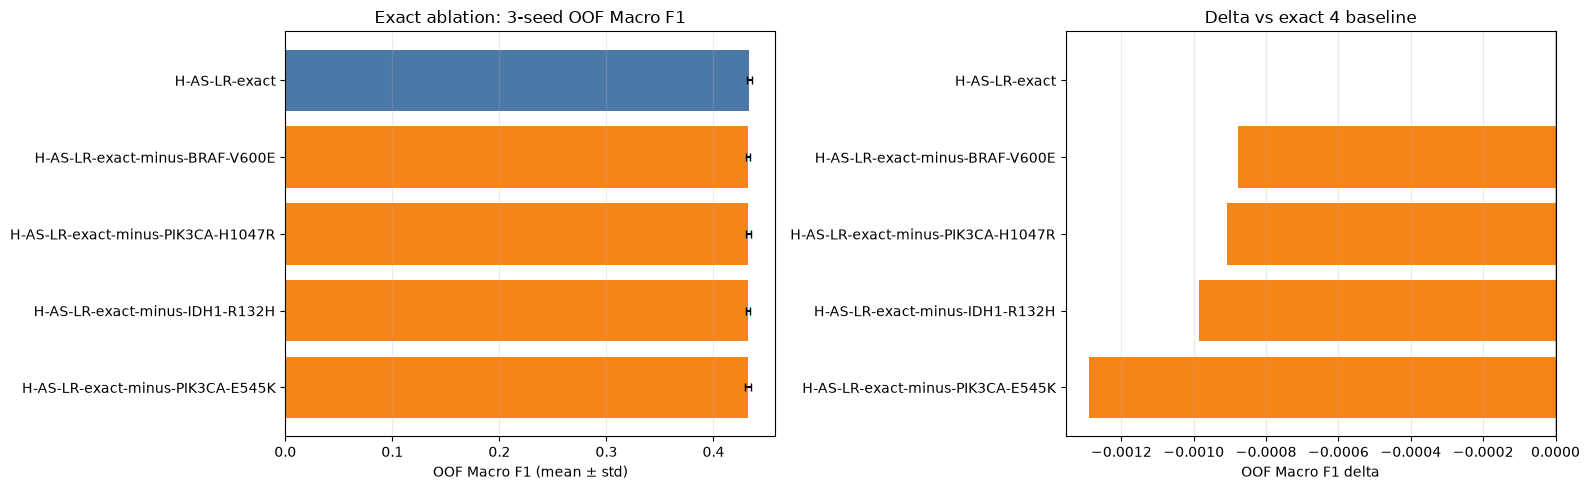

,experiment_id,oof_macro_f1_mean,oof_macro_f1_std,delta_vs_exact4,all_seed_positive_vs_exact4,convergence_warning_count,decision
0,H-AS-LR-exact,0.433479,0.002436,0.000000,False,15,기준
1,H-AS-LR-exact-minus-BRAF-V600E,0.432602,0.001793,-0.000877,False,15,유지
4,H-AS-LR-exact-minus-PIK3CA-H1047R,0.432571,0.002562,-0.000908,False,15,유지
2,H-AS-LR-exact-minus-IDH1-R132H,0.432494,0.001771,-0.000984,False,14,유지
3,H-AS-LR-exact-minus-PIK3CA-E545K,0.432189,0.002715,-0.001290,False,15,유지


In [8]:
if 'summary' in globals():
    plot_data = summary.sort_values('oof_macro_f1_mean').copy()
    colors = ['#4C78A8' if item == BASELINE else '#F58518' for item in plot_data['experiment_id']]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].barh(plot_data['experiment_id'], plot_data['oof_macro_f1_mean'], xerr=plot_data['oof_macro_f1_std'], capsize=3, color=colors)
    axes[0].set_title('Exact ablation: 3-seed OOF Macro F1')
    axes[0].set_xlabel('OOF Macro F1 (mean ± std)')
    axes[0].grid(axis='x', alpha=0.25)

    axes[1].barh(plot_data['experiment_id'], plot_data['delta_vs_exact4'], color=colors)
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_title('Delta vs exact 4 baseline')
    axes[1].set_xlabel('OOF Macro F1 delta')
    axes[1].grid(axis='x', alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(summary[['experiment_id', 'oof_macro_f1_mean', 'oof_macro_f1_std', 'delta_vs_exact4', 'all_seed_positive_vs_exact4', 'convergence_warning_count', 'decision']].sort_values('oof_macro_f1_mean', ascending=False))
else:
    print('세 seed 결과가 모두 있어야 시각화와 판정을 실행합니다.')